<a href="https://colab.research.google.com/github/shub1504/ML_Learning/blob/main/Multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

# Dono CSV files (watermelon.csv aur fertilizer.csv) ek saath ya ek-ek karke upload karein
uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)

Saving Dataset_1_watermelon.csv to Dataset_1_watermelon (1).csv
Uploaded file: Dataset_1_watermelon (1).csv


In [ ]:
from google.colab import files

# Dono CSV files (watermelon.csv aur fertilizer.csv) ek saath ya ek-ek karke upload karein
uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)

Saving Dataset_2_fertilizer.csv to Dataset_2_fertilizer (2).csv
Uploaded file: Dataset_2_fertilizer (2).csv


In [ ]:
import os
print("Current files in Colab:", os.listdir('.'))

Current files in Colab: ['.config', 'Dataset_1_watermelon.csv', 'Dataset_2_fertilizer (1).csv', 'Dataset_1_watermelon (1).csv', 'Dataset_2_fertilizer.csv', 'Dataset_2_fertilizer (2).csv', 'sample_data']


--- Multivariate Linear Regression Metrics ---
MSE         : 109065015.7461
RMSE        : 10443.4197
MAE         : 8625.1211
R2          : 0.9156
Adjusted R2 : 0.9128

--- Actual vs Predicted Yield Comparison (Last 10 Rows) ---
 Year  Yield  Predicted_Yield  Difference (Error)
 2015  89000     85166.574348         3833.425652
 2016  95000     78323.867795        16676.132205
 2017  91000     79011.434484        11988.565516
 2018 101000     83620.525668        17379.474332
 2019 100000     93184.089822         6815.910178
 2020 116000    105414.570993        10585.429007
 2021 119000     95691.261136        23308.738864
 2022 120000    101157.375390        18842.624610
 2023 126000    102085.350104        23914.649896
 2024 127811    115642.543638        12168.456362


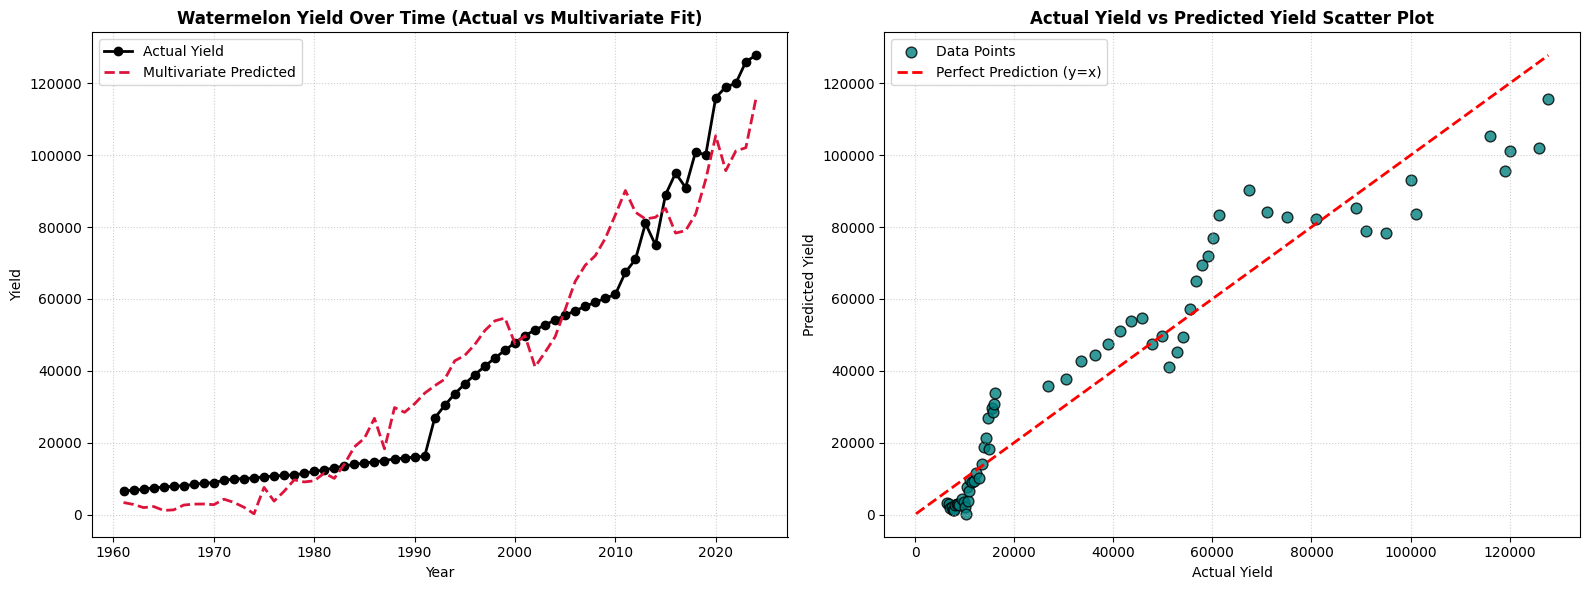

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Existing Files Loading
df_watermelon = pd.read_csv('Dataset_1_watermelon.csv')
df_fert = pd.read_csv('Dataset_2_fertilizer.csv')

# Essential columns extract aur rename
df_yield = df_watermelon[['Year', 'Value']].rename(columns={'Value': 'Yield'})
df_fertilizer = df_fert[['Year', 'Value']].rename(columns={'Value': 'Fertilizer_Use'})

# Year ke basis par merge
df_merged = pd.merge(df_yield, df_fertilizer, on='Year', how='inner').sort_values('Year')

# 2. Features (X) aur Target (Y)
X = df_merged[['Year', 'Fertilizer_Use']].values
Y = df_merged['Yield'].values

# Intercept column add karna [1, Year, Fertilizer]
X_design = np.hstack([np.ones((len(X), 1)), X])

# Normal Equation: Beta = (X^T * X)^(-1) * X^T * Y
beta_multi = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ Y
Y_pred = X_design @ beta_multi

# 3. All Accuracy Metrics Calculation
def calculate_all_metrics(y_true, y_pred, k_features):
    n = len(y_true)
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k_features - 1))

    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2, "Adjusted R2": adj_r2}

metrics = calculate_all_metrics(Y, Y_pred, k_features=2)

print("--- Multivariate Linear Regression Metrics ---")
for metric_name, value in metrics.items():
    print(f"{metric_name:<12}: {value:.4f}")

# 4. Actual vs Predicted Yield & Difference Table
df_merged['Predicted_Yield'] = Y_pred
df_merged['Difference (Error)'] = Y - Y_pred # Actual - Predicted Difference

print("\n--- Actual vs Predicted Yield Comparison (Last 10 Rows) ---")
print(df_merged[['Year', 'Yield', 'Predicted_Yield', 'Difference (Error)']].tail(10).to_string(index=False))

# 5. Visualizations Plotting (Two Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Actual vs Predicted Line Plot over Years
ax1.plot(df_merged['Year'], df_merged['Yield'], color='black', marker='o', linewidth=2, label='Actual Yield')
ax1.plot(df_merged['Year'], df_merged['Predicted_Yield'], color='crimson', linestyle='--', linewidth=2, label='Multivariate Predicted')
ax1.set_title('Watermelon Yield Over Time (Actual vs Multivariate Fit)', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Yield')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# Subplot 2: Actual vs Predicted Scatter Plot
ax2.scatter(Y, Y_pred, color='teal', alpha=0.8, edgecolors='k', s=60, label='Data Points')
min_val = min(Y.min(), Y_pred.min())
max_val = max(Y.max(), Y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')
ax2.set_title('Actual Yield vs Predicted Yield Scatter Plot', fontweight='bold')
ax2.set_xlabel('Actual Yield')
ax2.set_ylabel('Predicted Yield')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()